In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
# run code from data_input folder:# run code from data_input folder:
os.chdir('C:/Users/ccwis/OneDrive/Documents/1. MEng - Data Science/Project/factor_timing/data_input')

In [22]:


# ===========================
# LOAD DATA
# ===========================


preds = pd.read_csv("momentum_quality_probs.csv", parse_dates=['Date'])
#preds = preds.set_index('Date')


rets = pd.read_csv("cum_relative_factor_returns.csv", parse_dates=['Date'])
#rets = rets.set_index('Date')

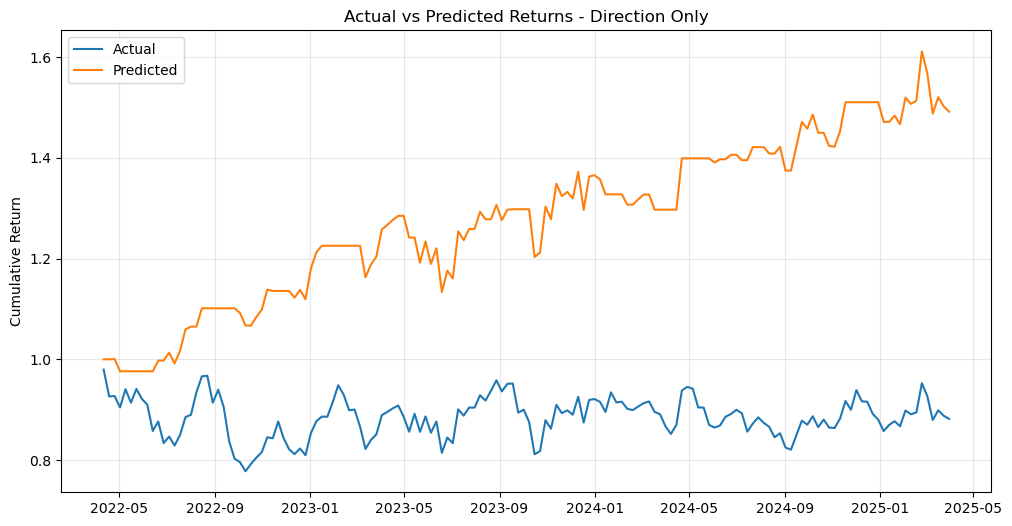

In [23]:


# ===========================
# MERGE ON DATE
# ===========================
df = preds.merge(rets, on="Date", how="inner")

# ===========================
# ACTUAL WEEKLY RETURN
# ===========================
df["actual_return"] = df["Momentum_vs_Quality"]

# ===========================
# PREDICTED RETURN (DIRECTION ONLY)
# prediction = 1 → take return
# prediction = 0 → take negative return
# ===========================
df["predicted_return"] = df["prediction"] * df["Momentum_vs_Quality"]

# ===========================
# CUMULATIVE RETURNS
# ===========================
df["actual_cum"] = (1 + df["actual_return"]).cumprod()
df["predicted_cum"] = (1 + df["predicted_return"]).cumprod()

# ===========================
# PLOT
# ===========================
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["actual_cum"], label="Actual")
plt.plot(df["Date"], df["predicted_cum"], label="Predicted")
plt.title("Actual vs Predicted Returns - Direction Only")
plt.ylabel("Cumulative Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


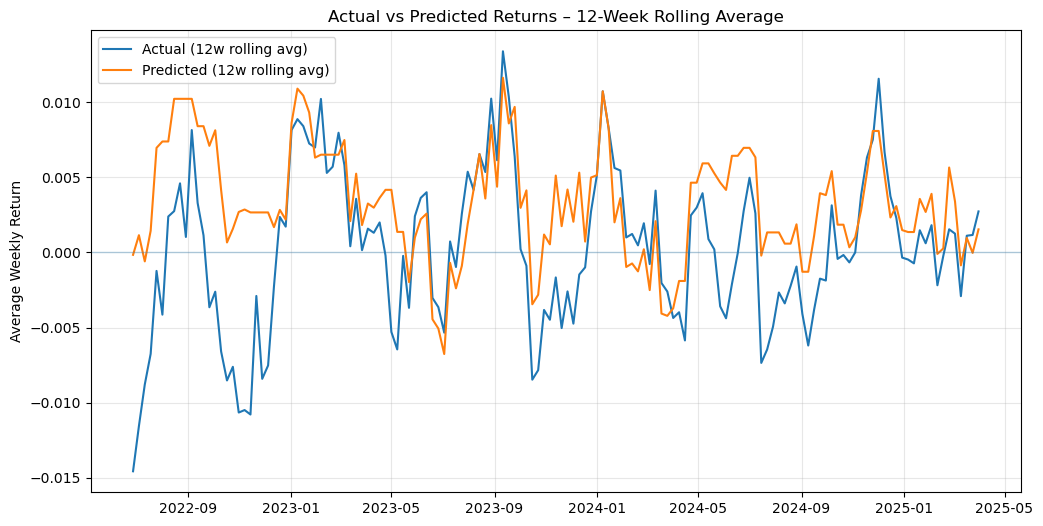

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ===========================
# MERGE ON DATE
# ===========================
df = preds.merge(rets, on="Date", how="inner").sort_values("Date")
df["Date"] = pd.to_datetime(df["Date"])

# ===========================
# WEEKLY RETURNS
# ===========================
df["actual_return"] = df["Momentum_vs_Quality"]
df["predicted_return"] = df["prediction"] * df["Momentum_vs_Quality"]

# ===========================
# 12-WEEK ROLLING AVERAGE (SMOOTHING)
# ===========================
ROLL_WEEKS = 12

df["actual_12w_avg"] = df["actual_return"].rolling(ROLL_WEEKS).mean()
df["predicted_12w_avg"] = df["predicted_return"].rolling(ROLL_WEEKS).mean()

# ===========================
# PLOT SMOOTHED RETURNS
# ===========================
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["actual_12w_avg"], label="Actual (12w rolling avg)")
plt.plot(df["Date"], df["predicted_12w_avg"], label="Predicted (12w rolling avg)")
plt.axhline(0, linewidth=1, alpha=0.3)
plt.title("Actual vs Predicted Returns – 12-Week Rolling Average")
plt.ylabel("Average Weekly Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


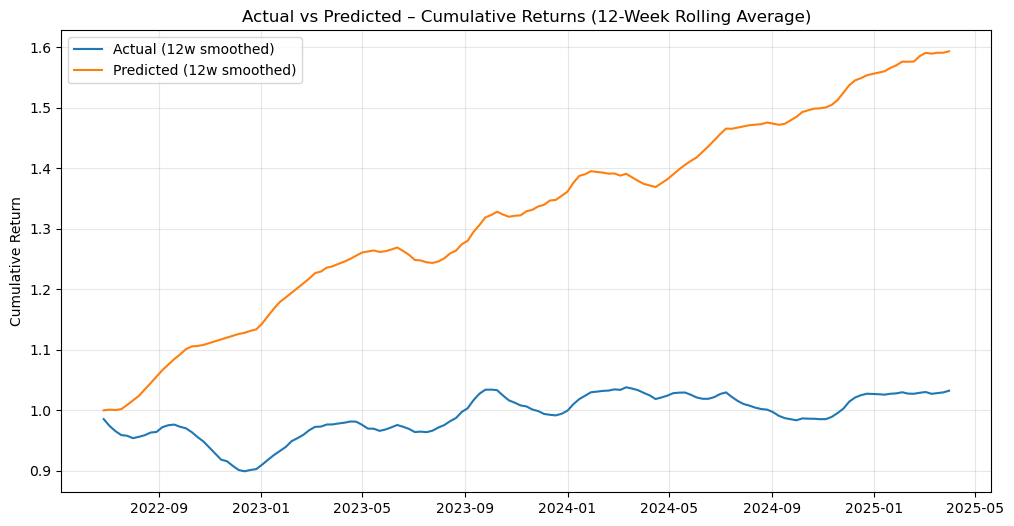

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# ===========================
# MERGE ON DATE
# ===========================
df = preds.merge(rets, on="Date", how="inner").sort_values("Date")
df["Date"] = pd.to_datetime(df["Date"])

# ===========================
# WEEKLY RETURNS
# ===========================
df["actual_return"] = df["Momentum_vs_Quality"]
df["predicted_return"] = df["prediction"] * df["Momentum_vs_Quality"]

# ===========================
# 12-WEEK ROLLING AVERAGE
# ===========================
ROLL_WEEKS = 12

df["actual_12w_avg"] = df["actual_return"].rolling(ROLL_WEEKS).mean()
df["predicted_12w_avg"] = df["predicted_return"].rolling(ROLL_WEEKS).mean()

# ===========================
# CUMULATIVE RETURNS (FROM SMOOTHED SERIES)
# ===========================
df["actual_cum_12w"] = (1 + df["actual_12w_avg"]).cumprod()
df["predicted_cum_12w"] = (1 + df["predicted_12w_avg"]).cumprod()

# ===========================
# PLOT
# ===========================
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["actual_cum_12w"], label="Actual (12w smoothed)")
plt.plot(df["Date"], df["predicted_cum_12w"], label="Predicted (12w smoothed)")
plt.title("Actual vs Predicted – Cumulative Returns (12-Week Rolling Average)")
plt.ylabel("Cumulative Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
